# **Máquinas de Vetores de Suporte:**
<font size=3>

**Máquina de Vetores de Suporte** (*Support Vector Machine* &mdash; SVM) constitui uma classe de modelos de *aprendizado supervisionado e não-supervisionado* fundamentada em **técnicas de otimização** de função de custo. O SVM é apresentado como um método que busca encontrar o *hiperplano* que maximiza a margem entre as amostras de diferentes classes, garantindo a melhor separação possível no espaço de atributos.

## **1. Introdução:**
<font size=3>

Imagine que temos dados de duas classes (ex: "círculo-azul" e "círculo-vermelho") e queremos traçar uma linha reta para separá-los. Como você pode ver, existem *várias* linhas possíveis que separam os dados perfeitamente. A Regressão Logística nos daria uma boa linha, mas ela se preocupa principalmente com a probabilidade de cada ponto pertencer a uma dada classe.


In [1]:
import matplotlib.pyplot as plt
from sklearn import datasets

X:(100, 2), y:(100,)



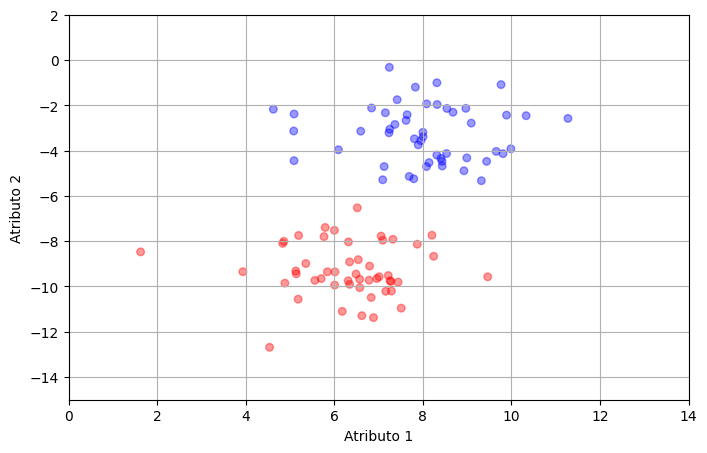

In [2]:
# simulando um conjundo de dados:
X, y = datasets.make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=1.3)

print(f"X:{X.shape}, y:{y.shape}\n")

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=30, alpha=0.4)
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.ylim(-15, 2)
plt.xlim(0, 14)
plt.grid()
plt.show()


<font size=3>

O SVM faz uma pergunta diferente: **Qual é a "melhor" linha que separa as duas classes?**

A intuição do SVM é que a "melhor" linha (ou **hiperplano**, em mais dimensões) é aquela que está o mais longe possível de *todos* os pontos de ambas as classes.

> **Analogia:** O SVM tenta encontrar a "rua" mais larga possível que separa as duas classes. A linha central dessa rua é o nosso classificador.

  * Os "limites" dessa rua tocam os pontos mais próximos de cada classe.
  * Esses pontos que definem os limites são chamados de **Vetores de Suporte** (Support Vectors), pois são eles que "suportam" e definem o classificador.

Aqui, iremos explorar como o SVM encontra essa "rua", o que acontece quando os dados não são perfeitamente separáveis e como ele usa um "truque" genial (os *kernels*) para lidar com dados complexos e não-lineares.

## **2. SVM's linears:**
<font size=3>

Para o cenário onde os dados são linearmente separáveis, queremos encontrar um hiperplano que maximize a **margem**: a distância entre o hiperplano e os pontos de dados mais próximos de cada classe — os **vetores de suporte**.

<font size=3>

Assim, vamos assumir que nossas duas classes são rotuladas como $y_i = +1$ e $y_i = -1$. O **hiperplano** que separa ambas as classes é definida pela equação da reta (n-dimensional):
$$
    \textbf{w}\cdot \textbf{x}_i + b = 0 \, ,
$$
onde $\textbf{x}_i$ correspondem ao **vetor de atributos** da amostra $i$, $\textbf{w}$ é o **vetor de pesos** (*weights*), e $b$ é o **variável viés** (*bias*).

### **2.1 Margens rígidas:**
<font size=3>

A fim de calcularmos a margem, vamos definir a distância entre dois pontos suporte como $\textbf v = \textbf x_+ - \textbf x_-$. Assim, a margem é dada pela projeção,
$$
    \text{Margem} = \frac{|\textbf v\cdot \textbf w|}{||\textbf w||} \, ,
$$
onde $||\textbf w||$ é a magnitude do vetor de pesos. Como $\textbf w\cdot \textbf x_{\pm} = \pm 1 - b$, a largura da margem fica
$$
    \text{Margem} = \frac{2}{||\textbf w||} \, .
$$

Agora temos a seguinte **restrição**: *todos os pontos devem estar do lado correto da sua respectiva margem.*
 * Para pontos positivos ($y_i = +1$): $\,\textbf w \cdot \textbf x_i + b \ge +1$
 * Para pontos negativos ($y_i = -1$): $\,\textbf w \cdot \textbf x_i + b \le -1$

Desta forma, o **problema de otimização** de uma SVM (de margem rígida) é **maximizar** a margem,

$$
    2/||\textbf w|| \, ,
$$
o que é o mesmo que **minimizar** seu valor inverso. Por conveniência matemática (cálculo de derivada), o algoritmo realiza a minimização de
$$
    \frac12 ||\textbf w||^2 \, ,
$$
dado que
$$
    y_i(w \cdot x_i + b) \ge 1 \, .
$$


<font size=3>

Em tarefas de classificação, podemos usar o [`SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) (*Suport Vector Classifier*) do scikit-learn.

In [3]:
import numpy as np
from sklearn import datasets
from sklearn.svm import SVC # Support Vector Classifier

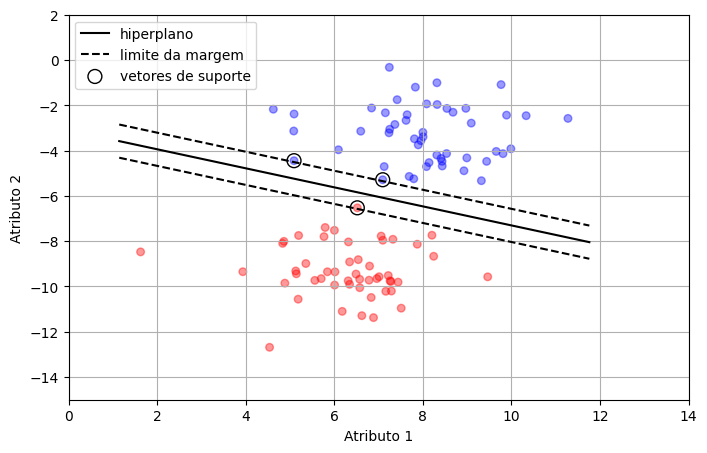

In [4]:
# treinando o modelo SVM linear com margem rígida:
model = SVC(kernel='linear')
model.fit(X, y)

# Plot
def plot_svm(model, X, y):

    plt.figure(figsize=(8, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=30, alpha=0.4)

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # hiperplano:
    x = np.linspace(xlim[0], xlim[1])

    w = model.coef_[0]
    b = model.intercept_[0]

    # w0·x0 + w1·x1 + b = 0  ->  x1 = y_line = -w0·x0/w1 - b/w1
    y_line = -(w[0]*x + b)/w[1]

    # margens:
    margin = 1/np.linalg.norm(w)

    y_margin_up = y_line + margin
    y_margin_down = y_line - margin

    plt.plot(x, y_line, 'k-', label="hiperplano")
    plt.plot(x, y_margin_up, 'k--', label="limite da margem")
    plt.plot(x, y_margin_down, 'k--')

    # vetores de suporte:
    plt.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=100, facecolors='none', edgecolors='k',
                label="vetores de suporte")

    plt.xlabel("Atributo 1")
    plt.ylabel("Atributo 2")
    plt.ylim(-15, 2)
    plt.xlim(0, 14)
    plt.legend()
    plt.grid()
    plt.show()

plot_svm(model, X, y)

<font size=3>

> **Observação:** realize **sempre** a normalização dos dados para aplicar em modelos SVM, já que as distâncias no espaço de atributos são afetadas pelas dimensões e unidades dos eixos.

### **2.2 Margem suave:**
<font size=3>

Em muitos casos, os dados **não podem ser separados de forma perfeitamente linear** — alguns pontos podem estar muito próximos do hiperplano ou até do lado errado, o que **pode causar erros de classificação**.

Para lidar com isso sem forçar um hiperplano com margens rígidas, introduziremos as **variáveis de folga** $\xi_i$, tal que
$$
    y_i\left(\textbf w\cdot\textbf x_i + b\right) \geq 1 - \xi_i \, ,
$$
onde:
 - $\xi_i$ representa o quanto o ponto $i$ tem permissão para "violar" a margem. Esses valores são calculados, assim como $\textbf w$ e $b$, durando a otimização do modelo.
 - Se $\xi_i = 0$, o ponto está do lado correto e fora da margem (perfeito).
 - Se $0 < \xi_i \le 1$, o ponto está *dentro* da margem, mas ainda do lado correto.
 - Se $\xi_i > 1$, o ponto está do lado *errado* da fronteira (erro de classificação).

Mas agora, a variável de folga muda o problema otimização do modelo. O algoritmo irá minimizar
$$
    \frac12||\textbf w||^2 + C\sum_i \xi_i \, ,
$$
onde o hiperparâmetro $C$ regula a tolerância de violações de pontos que passam para dentro da margem:
- Valor de `C` **pequeno** (ex: 0.1), a margem **enlarguece** e é violada com mais frequência, o que pode levar à **_underfitting_** (alto viés e baixa variância);
- Valor de `C` **grande** (ex: 100), a margem fica **estreita**, o que pode levar à **_overfitting_** (baixo viés e alta variância).
  

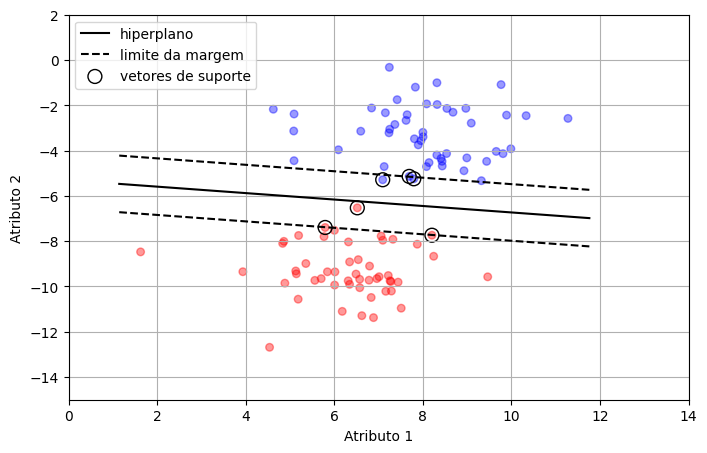

In [5]:
# adotando valor menor de C:
model = SVC(kernel='linear', C=0.2)
model.fit(X, y)

plot_svm(model, X, y)

## **3. SVM's não-lineares:**
<font size=3>

Mas... e se os dados não puderem ser separados por uma linha reta?

In [6]:
from sklearn.datasets import make_moons

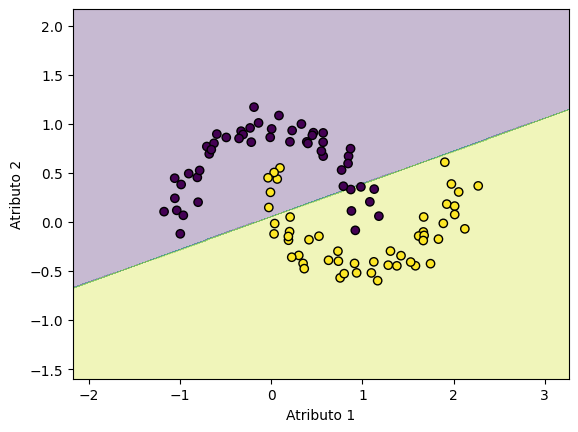

In [7]:
# simulando dados não-lineares (em formato de luas):
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

# definindo o modelo SVM com Kernel (função) linear:
model = SVC(kernel='linear', C=1.0)
model.fit(X, y)

def plot_svm2(model, X, y):

    # plot da fronteira de decisão:
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    x_axis, y_axis = np.meshgrid(np.arange(x_min, x_max, 0.01),
                                 np.arange(y_min, y_max, 0.01))

    Z = model.predict(np.c_[x_axis.ravel(), y_axis.ravel()]).reshape(x_axis.shape)

    plt.contourf(x_axis, y_axis, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.xlabel("Atributo 1")
    plt.ylabel("Atributo 2")
    plt.show()

plot_svm2(model, X, y)

<font size=3>

Qual é a solução? Se os dados não são linearmente separáveis no espaço em que vivem (no nosso caso, 2D), **vamos projetá-los para um espaço de dimensão maior onde eles *se tornem* linearmente separáveis.**


<font size=3><center>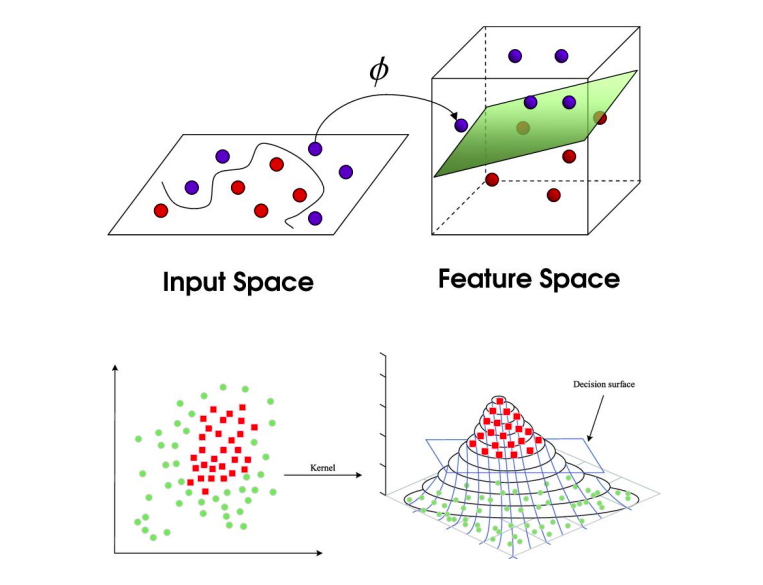</center>

<font size=3>

Para isso, utilizaremos o artifício matemático da **função kernel** $K(x_i,\, x_j)$, que mapeia dois pontos de atributos em dimensões mais altas.

- **Kernel Polinomial:**
  * $K(a, b) = (\gamma\,(a \cdot b) + r)^d$
  * Simula a criação de atributos polinomiais de grau $d$.
  * **Hiperparâmetros:** ($\gamma$, $r$, $d$).
  <br>

- **Kernel Gaussiano (_radial basis function_ — RBF):**
  * $K(a, b) = \exp(-\gamma ||a - b||^2)$.
  * **Hiperparâmetro:** ($\gamma$).
    

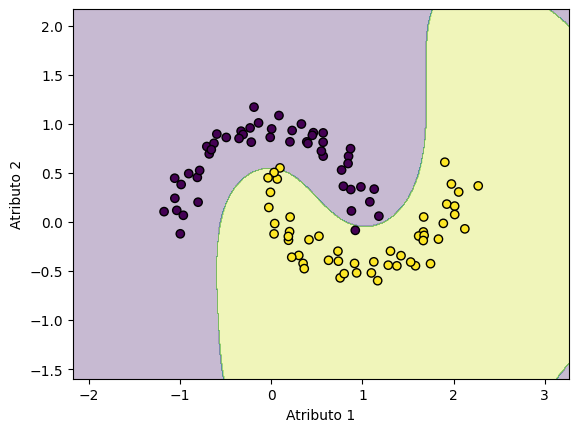

In [8]:
# definindo o modelo SVM com Kernel RBF (gaussiano):
model = SVC(kernel='rbf', gamma=1.0, C=1.0)  # gamma controla a flexibilidade
model.fit(X, y)

plot_svm2(model, X, y)

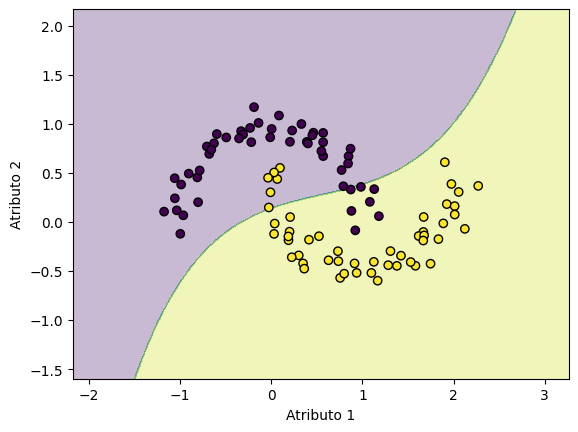

In [9]:
# definindo o modelo SVM com Kernel RBF (gaussiano):
model = SVC(kernel='rbf', gamma=0.2, C=1.0)
model.fit(X, y)

plot_svm2(model, X, y)

## **4. SVM em tarefas de regressão:**
<font size=3>

O SVM é um algoritmo versátil e pode ser estendido para problemas de **regressão** (*Support Vector Regressor* — SVR).

<font size=3>

A intuição por trás do SVR é bastante diferente do SVC:

  * **SVC (Classificação):** Queremos a "rua" (margem) mais **larga** possível que **separa** as duas classes. Pontos dentro da margem ou do lado errado são penalizados.

  * **SVR (Regressão):** Queremos encontrar a "rua" (margem) **mais estreita** possível que **contém** o máximo de pontos. A "rua" é como um **tubo de tolerância** ao redor da nossa linha de predição.

Por exemplo, seja a função linear $f(\mathbf{x}) = \mathbf{w}\cdot \mathbf{x} + b$ que minimize erros dentro de uma margem $\epsilon$, a otimização tenderia a calcular valores cada vez menores de
$$
    \max(0,\, |y - f(\mathbf{x})| - \epsilon) \, .
$$

In [10]:
from sklearn.svm import SVR # Support Vector Regressor

# simulando os dados:
X = np.sort(np.random.rand(40, 1)*5, axis=0)
y = np.sin(X).ravel() + 0.1*np.random.randn(40)

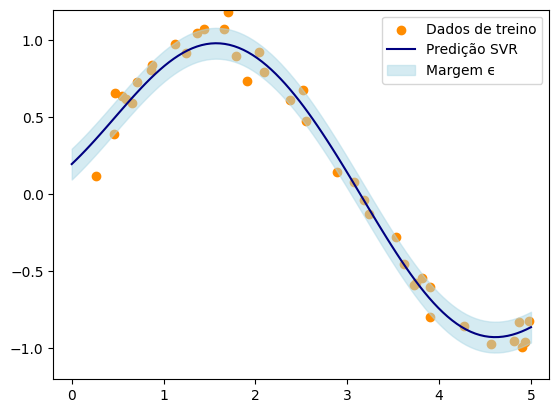

In [11]:
# definindo o modelo SVR:
ϵ = 0.1
model = SVR(kernel='rbf', C=1.0, epsilon=ϵ)
# ajustando ϵ, o modelo ignora mais ruídos pequenos.
# ajustando C, o modelo tenta ajustar mais aos dados.

model.fit(X, y)

def plot_svm3(model, X, y=None):

    X_axis = np.linspace(0, 5, 100).reshape(-1, 1)
    y_pred = model.predict(X_axis)

    plt.scatter(X, y, color='darkorange', label='Dados de treino')
    plt.plot(X_axis, y_pred, color='navy', label='Predição SVR')
    plt.fill_between(X_axis.ravel(), y_pred-ϵ, y_pred+ϵ, color='lightblue',
                     alpha=0.5, label='Margem ϵ')

    plt.xlim(-0.2, 5.2)
    plt.ylim(-1.2, 1.2)
    plt.legend()
    plt.show()

plot_svm3(model, X, y)

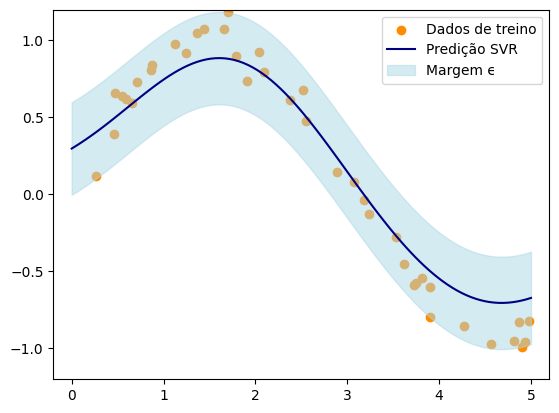

In [12]:
# definindo o modelo SVR:
ϵ = 0.3
model = SVR(kernel='rbf', C=1.0, epsilon=ϵ)
# ajustando ϵ, o modelo ignora mais ruídos pequenos.
# ajustando C, o modelo tenta ajustar mais aos dados.

model.fit(X, y)

plot_svm3(model, X, y)

<font size=3>
<br>
    
| Parâmetro | Valor | Efeito na Margem/Tubo | Efeito na Linha de Predição / Modelo | Risco |
| :-------- | :---- | :-------------------- | :---------------------------------- | :---- |
| **$\epsilon$** | **Baixo** (ex: 0.1) | Tubo de tolerância **estreito**. | Modelo tenta se ajustar muito aos pontos para evitar que saiam do tubo, resultando em uma linha de predição mais "ondulada". | Overfitting (sensível a ruído) |
|           | **Alto** (ex: 1.0)  | Tubo de tolerância **largo**.   | Modelo tem mais "liberdade" e a linha de predição é mais suave, ignorando as variações menores nos dados. | Underfitting (ignora detalhes) |
| **C** | **Baixo** | Modelo mais tolerante com violações fora do tubo. | Prioriza uma linha de predição mais suave, mesmo que mais pontos saiam do tubo. | Underfitting (modelo muito simples) |
|           | **Alto** | Modelo menos tolerante com violações fora do tubo. | Tenta fortemente manter os pontos dentro do tubo, resultando em uma linha de predição que se ajusta mais aos dados. | Overfitting (modelo muito complexo) |


## **5. Vantagens e limitações:**
<font size=3>
    
Os modelos SVM destacam-se pela sua **eficácia e versatilidade**. São particularmente fortes em espaços de alta dimensão e com poucos dados, graças à sua sólida base teórica que garante um ótimo global. O "Truque do Kernel" permite-lhes resolver problemas não-lineares de forma eficiente sem computar explicitamente dimensões extras, e a capacidade de usar margens suaves ou tubos de tolerância os torna robustos a outliers, além de serem eficientes em memória ao focar apenas nos vetores de suporte.

Contudo, os SVMs possuem desafios significativos. A **escolha e ajuste de seus múltiplos hiperparâmetros** (como C, gamma e epsilon) pode ser complexa e consumir tempo. Eles também são **sensíveis ao escalonamento dos dados**, exigindo normalização ou padronização. Para conjuntos de dados muito grandes, o treinamento pode se tornar **excessivamente demorado**, e a **interpretabilidade de suas decisões é baixa**, especialmente com kernels não-lineares. Além disso, são inerentemente binários, demandando estratégias mais complexas para problemas multi-classe.

## __Referências:__
<font size=3>

- **(7.2)**: K. Faceli, _Inteligência artificial: uma abordagem de aprendizado de máquina_. Grupo Gen - LTC, 2011.
- [Support Vector Machine (SVM) in 2 minutes](https://www.youtube.com/watch?v=_YPScrckx28&t);
- [The Kernel Trick in Support Vector Machine (SVM)](https://www.youtube.com/watch?v=Q7vT0--5VII).
  